# La Régression Logistique

## Veille technologique

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)

# ── Style global des graphiques ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize"   : (10, 5),
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 12,
})

### Projet : Cardiovascular Risks

---

## Contexte

Ce notebook constitue la veille technologique sur la **régression logistique**,
réalisée dans le cadre du projet *Cardiovascular Risks*.

L'objectif du projet est de prédire si un patient présente un **risque
cardio-vasculaire** (variable binaire : 0 = pas de risque, 1 = à risque),
à partir de données médicales (âge, tabagisme, cholestérol, tension artérielle, etc.).

La régression logistique est un algorithme de **classification supervisée**
particulièrement adapté à ce type de problème binaire.

---

## Plan de la veille technologique

1. Pourquoi pas la régression linéaire ?
2. Définition et cas d'usage de la régression logistique
3. Le Composant Linéaire
4. La fonction sigmoïde
5. La fonction de coût — log loss
6. Optimisation et Apprentissage
7. Simulation Pratique (Scénario Arkose)

---

## 1. Pourquoi pas la régression linéaire ?

La visualisation ci-dessous illustre le problème concret :
la régression linéaire produit des valeurs hors de [0, 1],
ce qui est mathématiquement impossible pour une probabilité.

In [2]:
np.random.seed(42)

# np.array() : crée un tableau numpy (structure de données optimisée pour le calcul)
# Ici on simule deux groupes de patients avec une mesure de concentration protéique
sains = np.array([1.0, 1.5, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2, 3.5, 3.8])
malades = np.array([5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5])

# np.concatenate() : fusionne plusieurs tableaux en un seul sur un axe donné
# Résultat : un seul tableau X avec les 20 patients
X = np.concatenate([sains, malades])  # shape (20,) → [1.0, 1.5, ..., 9.0, 9.5]

# np.array([0]*10 + [1]*10) : crée les étiquettes (labels)
# [0]*10 → [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (les 10 sains)
# [1]*10 → [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  (les 10 malades)
# + concatène les deux listes Python avant de les convertir en array numpy
y = np.array([0]*10 + [1]*10)         # shape (20,) → [0,0,...,1,1]

In [3]:
print("X (concentrations) :", X)
print("y (labels) :", y)
print("Taille X :", X.shape, "| Taille y :", y.shape)

X (concentrations) : [1.  1.5 2.  2.2 2.5 2.8 3.  3.2 3.5 3.8 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]
y (labels) : [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Taille X : (20,) | Taille y : (20,)


#### Aparté — Qu'est-ce qu'un polynôme ?

Avant de continuer, comprenons ce qu'utilise `np.polyfit` sous le capot.

Un **polynôme de degré n** est une expression de la forme :

$$f(x) = a_n x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0$$

Dans notre cas, on utilise un **polynôme de degré 1**, c'est-à-dire une simple **droite** :

$$f(x) = ax + b$$

- $a$ : la **pente** — de combien monte (ou descend) la droite quand x augmente d'une unité
- $b$ : l'**ordonnée à l'origine** — la valeur de f(x) quand x = 0

**Dans le contexte médical de ce projet :**

`np.polyfit(X, y, 1)` cherche la droite $ax + b$ qui colle au mieux
à nos données patients — c'est-à-dire qui minimise l'écart entre
la droite et les vraies étiquettes (0 = sain, 1 = malade).

`np.polyval(coeffs, x_range)` applique ensuite cette droite à une
série de valeurs pour tracer la courbe.


In [4]:
# ── Régression linéaire manuelle ───────────────────────────────────────────────
# np.polyfit(X, y, 1) : calcule les coefficients d'un polynôme de degré 1 (droite)
# Renvoie [pente, ordonnée_à_l_origine] qui minimisent l'erreur quadratique
coeffs= np.polyfit(X,y, 1) # 1 représente le degré de ce polynome = 1 droite
print("\nCoefficients régression linéaire -> pente :", round(coeffs[0], 3), "| biais :", round(coeffs[1], 3))


Coefficients régression linéaire -> pente : 0.17 | biais : -0.333


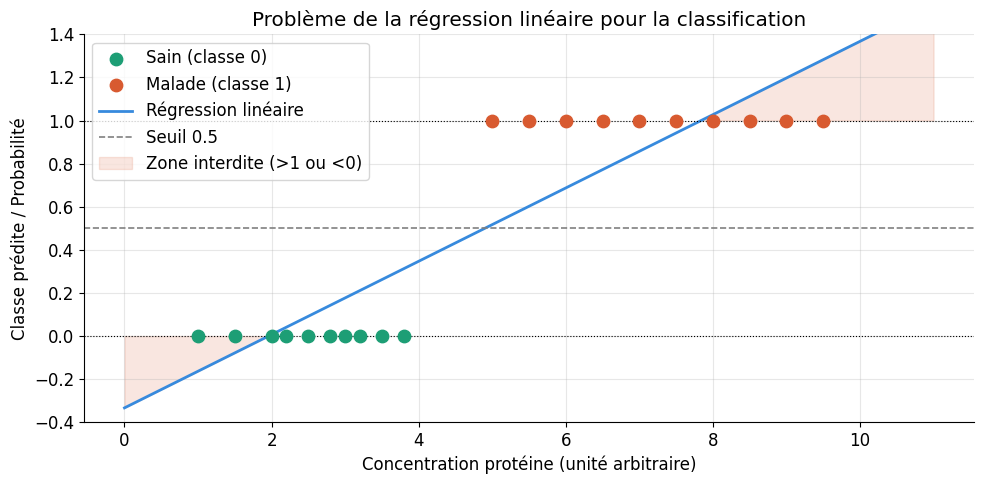


Observation : la droite dépasse [0,1] → les prédictions ne sont pas des probabilités valides.


In [5]:
# np.linspace(0, 11, 300) : génère 300 points régulièrement espacés entre 0 et 11
# Sert à tracer une courbe lisse (plus de points = courbe plus lisse)
x_range = np.linspace(0, 11, 300)

# np.polyval(coeffs, x_range) : évalue le polynôme pour chaque valeur de x_range
# Equivalent à : y = pente * x + biais
y_linear = np.polyval(coeffs, x_range)

# fig : la figure globale (le "cadre")
# ax  : les axes sur lesquels on dessine (le "graphique")
fig, ax = plt.subplots(figsize=(10, 5))

# ax.scatter() : nuage de points
# [0]*10 : liste Python de 10 zéros → position y de tous les patients sains
ax.scatter(sains, [0]*10, color="#1D9E75", s=80, zorder=5, label="Sain (classe 0)")
ax.scatter(malades, [1]*10, color="#D85A30", s=80, zorder=5, label="Malade (classe 1)")
# s=80     : taille des points
# zorder=5 : priorité d'affichage (dessiné par-dessus les autres éléments)

# ax.plot() : trace une ligne continue
ax.plot(x_range, y_linear, color="#378ADD", lw=2, label="Régression linéaire")
# lw=2 : épaisseur de la ligne (linewidth)

# ax.axhline() : trace une ligne horizontale sur toute la largeur du graphique
ax.axhline(0.5, color="gray",  lw=1.2, linestyle="--", label="Seuil 0.5")
ax.axhline(0,   color="black", lw=0.8, linestyle=":")
ax.axhline(1,   color="black", lw=0.8, linestyle=":")

# ax.fill_between() : colorie la zone entre deux courbes
# where= : condition booléenne — ne colorie que là où la condition est vraie
# Ici on colorie là où la droite dépasse 1 (zone mathématiquement interdite)
ax.fill_between(x_range, 1, y_linear,
                where=y_linear > 1,
                color="#D85A30", alpha=0.15, label="Zone interdite (>1 ou <0)")
ax.fill_between(x_range, y_linear, 0,
                where=y_linear < 0,
                color="#D85A30", alpha=0.15)
# alpha=0.15 : transparence (0=invisible, 1=opaque)

ax.set_xlabel("Concentration protéine (unité arbitraire)")
ax.set_ylabel("Classe prédite / Probabilité")
ax.set_title("Problème de la régression linéaire pour la classification")
ax.set_ylim(-0.4, 1.4)  # fixe les limites de l'axe y
ax.legend(loc="upper left")
plt.tight_layout()       # ajuste automatiquement les marges pour éviter les coupures
plt.show()

print("\nObservation : la droite dépasse [0,1] → les prédictions ne sont pas des probabilités valides.")

La régression linéaire est inadaptée à la classification pour trois raisons fondamentales :

**1. Prédictions hors limites** : Une droite peut prédire des valeurs inférieures à 0 ou supérieures à 1 (par exemple 1.4 ou -0.2), ce qui est absurde pour une probabilité. La régression logistique utilise la fonction **Sigmoïde** pour garantir un résultat toujours compris entre 0 et 1.

**2. Sensibilité aux valeurs extrêmes** : Si l'on ajoute un point très éloigné (outlier), la droite pivote pour réduire l'écart, ce qui déplace mécaniquement le seuil de décision (0.5) et fausse les prédictions pour les autres points. La courbe logistique est beaucoup plus stable car elle sature à 1, ignorant l'influence disproportionnée des valeurs très hautes.

**3. Nature du changement** : La régression linéaire suppose une progression constante du risque. En réalité, les phénomènes biologiques suivent souvent une **courbe en S** : le risque est faible et stable, explose soudainement autour d'un seuil critique, puis sature à nouveau. C'est exactement ce que modélise la régression logistique.

## Présentation de la Régression Logistique

---

#### 2. Définition et Cas d'Usage
La **régression logistique** est un mécanisme extrêmement efficace pour calculer des probabilités. Contrairement à la régression linéaire qui prédit des valeurs continues, la régression logistique produit un résultat probabiliste (entre 0 et 1).

Les probabilités en retour peuvent être employées de deux manières :
* **Utilisation du résultat brut :** Si le modèle génère une valeur de **0,865**, cela implique une probabilité de **86,5 %** que l'événement se produise (ex: une pathologie ou un abonnement).
* **Conversion en valeur binaire :** Utilisation d'un seuil (ex: 0,5) pour classer l'individu en **True** ou **False**. C'est pour cette raison que l'on parle de **classification**.

---

#### 3. Le Composant Linéaire ($z$)
Le cœur de la régression logistique repose sur une combinaison linéaire, identique à celle de la régression linéaire :

$$z = b + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

Où :
* **$z$** est le résultat de l'équation (également appelé *log-odds*).
* **$b$** correspond au biais (l'ordonnée à l'origine).
* **$w$** sont les pondérations (poids) apprises par le modèle.
* **$x$** sont les caractéristiques (features) de l'exemple particulier.


#### 4. Fonction Sigmoïde
Pour s'assurer que les résultats soient toujours compris entre **0** et **1**, on injecte le score $z$ dans une fonction de la famille des fonctions logistiques : la **sigmoïde**.

$$f(x) = \frac{1}{1 + e^{-x}}$$

* **$e$** est le nombre d'Euler ($\approx 2,718$).
* **$x$** (ou $z$) est l'entrée de la fonction.

**Observation :** Plus $z$ augmente, plus la sortie s'approche de **1** sans jamais l'atteindre. Plus $z$ diminue, plus la sortie s'approche de **0**.

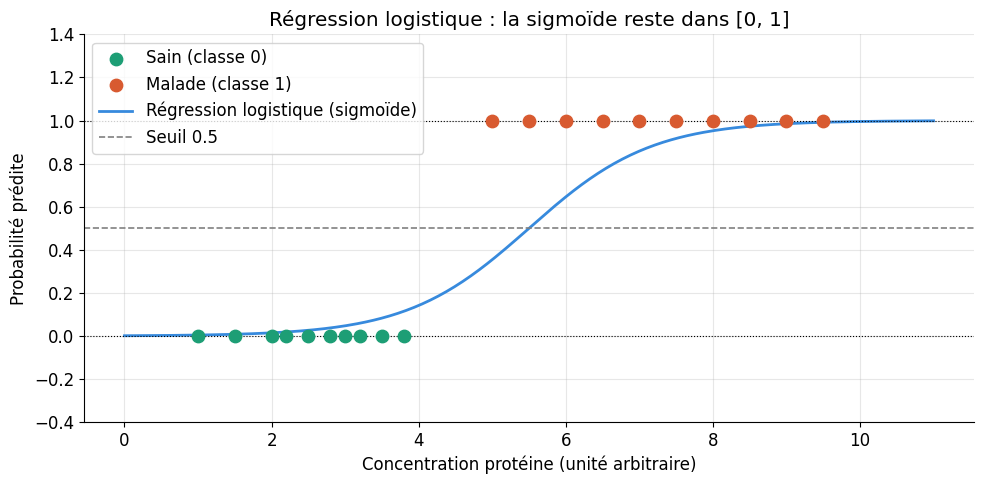


Observation : la sigmoïde reste toujours dans ]0, 1[ — sorties interprétables comme des probabilités.


In [10]:
x_range = np.linspace(0, 11, 300)

# Sigmoïde centrée sur le milieu de la plage, pente contrôlée
x0 = 5.5   # point d'inflexion (centre du S)
k  = 1.2   # pente (plus k est grand, plus le S est raide)
y_sigmoid = 1 / (1 + np.exp(-k * (x_range - x0)))

fig, ax = plt.subplots(figsize=(10, 5))

# Nuage de points : patients sains (y=0) et malades (y=1)
ax.scatter(sains,   [0]*10, color="#1D9E75", s=80, zorder=5, label="Sain (classe 0)")
ax.scatter(malades, [1]*10, color="#D85A30", s=80, zorder=5, label="Malade (classe 1)")

# Courbe sigmoïde en forme de S
ax.plot(x_range, y_sigmoid, color="#378ADD", lw=2, label="Régression logistique (sigmoïde)")

# Lignes de référence : seuil de décision et bornes [0, 1]
ax.axhline(0.5, color="gray",  lw=1.2, linestyle="--", label="Seuil 0.5")
ax.axhline(0,   color="black", lw=0.8, linestyle=":")
ax.axhline(1,   color="black", lw=0.8, linestyle=":")

ax.set_xlabel("Concentration protéine (unité arbitraire)")
ax.set_ylabel("Probabilité prédite")
ax.set_title("Régression logistique : la sigmoïde reste dans [0, 1]")
ax.set_ylim(-0.4, 1.4)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("\nObservation : la sigmoïde reste toujours dans ]0, 1[ — sorties interprétables comme des probabilités.")

#### 5. Perte Logistique (Log Loss)
Contrairement à la régression linéaire qui utilise la perte quadratique, nous utilisons ici la **Perte Logistique**. Elle mesure l'écart entre la prédiction $\hat{y}$ et la réalité $y$ :

$$Loss = -(y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}))$$

* **Si $y=1$ :** Seule la partie gauche $-\log(\hat{y})$ est active. Elle punit si la prédiction est proche de 0.
* **Si $y=0$ :** Seule la partie droite $-\log(1 - \hat{y})$ est active. Elle punit si la prédiction est proche de 1.

**Avantages :** Elle est **convexe** (facilite l'optimisation) et force le modèle à être honnête sur son niveau de confiance (punition sévère des erreurs "arrogantes").

---

#### 6. Optimisation et Apprentissage
L'apprentissage consiste à ajuster $w$ et $b$ via la **descente de gradient** pour minimiser la moyenne des pénalités sur le dataset.

#### Calcul du Gradient ($\nabla$)
Il indique la direction de l'erreur pour corriger les poids :
* **Erreur** : $E = (\hat{y} - y)$
* **Gradient pour $w$** : $\nabla_w = E \times x$
* **Gradient pour $b$** : $\nabla_b = E$

#### Mise à jour (Learning Rate)
On utilise une vitesse d'apprentissage ($\eta$) pour modifier les paramètres :
$$w_{nouveau} = w_{actuel} - (\eta \times \nabla_w)$$

---

#### 7. Simulation Pratique (Scénario Arkose)
**Données :** Un client avec **$x=2$** sessions. Réalité **$y=1$** (abonné).
**Paramètres après un début d'apprentissage :** $w=1,5$ et $b=-2,0$.

#### Étape 1 : Score linéaire ($z$)
$$z = (1,5 \times 2) - 2,0 = 1,0$$
*Le score est positif, le modèle penche vers l'abonnement.*

#### Étape 2 : Probabilité ($\hat{y}$)
$$\hat{y} = \frac{1}{1 + e^{-1,0}} \approx \mathbf{0,73} \text{ (soit 73 %)}$$

#### Étape 3 : Perte (Loss)
$$Loss = -\ln(0,73) \approx \mathbf{0,31}$$
*La perte est modérée, le modèle a raison mais manque de certitude.*

#### Étape 4 : Correction (Gradient)
Pour une vitesse $\eta = 0,1$ :
1. **Erreur :** $0,73 - 1,0 = -0,27$
2. **$\nabla_w$ :** $-0,27 \times 2 = -0,54$
3. **Mise à jour de $w$ :** $1,5 - (0,1 \times -0,54) = \mathbf{1,554}$
4. **Mise à jour de $b$ :** $-2,0 - (0,1 \times -0,27) = \mathbf{-1,973}$

**Résultat :** Le poids $w$ a augmenté et le biais $b$ est devenu moins négatif. Le modèle a "appris" pour être plus performant au prochain calcul.
